In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#50 x 50 pixels
img_size = 50
#https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/data

#location of the data
cat_data_folder = "PetImages/Cat"
dog_data_folder = "PetImages/Dog" 

In [3]:
def file_number(cat_file, dog_file):
    dog_counts = 0
    cat_counts = 0 
    for filename in os.listdir(dog_file):
        dog_counts += 1
    for filename in os.listdir(cat_file):
        cat_counts += 1
    print(f"Dog files: {dog_counts}, Cat files: {cat_counts}")
    
file_number(cat_data_folder, dog_data_folder)

Dog files: 12501, Cat files: 12501


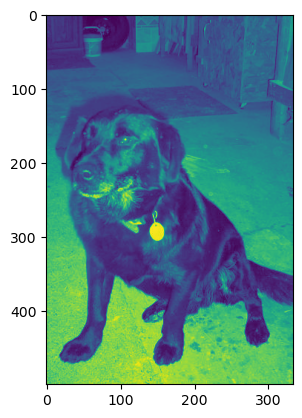

In [4]:
X = []
y = []
skipped = 0

for filename in os.listdir(dog_data_folder): #replace with cat
    full_path = os.path.join(dog_data_folder, filename)

    img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        skipped += 1
        continue
    plt.imshow(img)
    plt.show()
    break

In [ ]:
img_size = 50

def load_images(folder, label, img_size=50):
    X = []
    y = []
    skipped = 0

    for filename in os.listdir(folder):
        full_path = os.path.join(folder, filename)

        img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            skipped += 1
            continue
        
        try:
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
        except cv2.error:
            skipped += 1
            continue

        # Normalize to [0, 1] float32
        img = img.astype(np.float32) / 255.0
        

        X.append(img)
        y.append(label)

    X = np.stack(X, axis=0)               # (N, img_size, img_size, 1)
    y = np.asarray(y, dtype=np.int64)     # (N, 2)

    print(f"{folder}: {len(X)} loaded, {skipped} skipped")
    return X, y

In [ ]:
# One-hot labels: cat=[1,0],dog=[0,1]

X_cat, y_cat = load_images(cat_data_folder, [1, 0], img_size)
X_dog, y_dog = load_images(dog_data_folder, [0, 1], img_size)

X = np.concatenate([X_cat, X_dog], axis=0)
y = np.concatenate([y_cat, y_dog], axis=0)

perm = np.random.permutation(len(X))
X = X[perm]
y = y[perm]

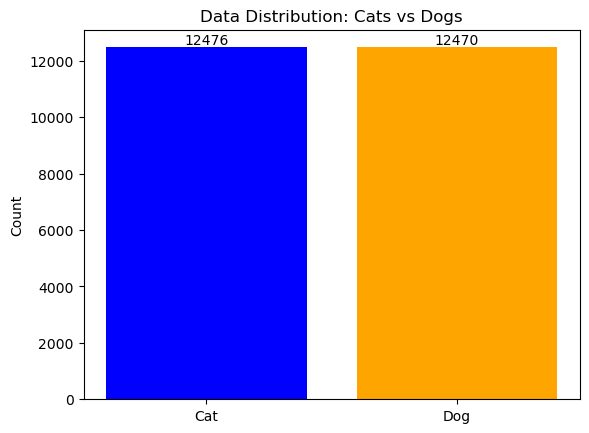

In [7]:
import matplotlib.pyplot as plt

# Count the occurrences of each label
label_counts = np.sum(y, axis=0)  # Sum along the rows to get counts for [cat, dog]

plt.bar(['Cat', 'Dog'], label_counts, color=['blue', 'orange'])
plt.title('Data Distribution: Cats vs Dogs')
plt.ylabel('Count')


for i, count in enumerate(label_counts):
    plt.text(i, count + 10, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

In [ ]:
print("X_data:", np.array(X).shape)
print("y_data:", np.array(y).shape)

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

In [ ]:
# np.save("model/catdog_X.npy", X)
# np.save("model/catdog_y.npy", y)